In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qpmr
import qpmr.plot

is_logger_initialized = False
if not is_logger_initialized:
    logger = qpmr.init_logger(level="DEBUG")
    is_logger_initialized = True

In [2]:
region = (-12, 1, -0.1, 5000)

# Gi - identified system
Gi_num = np.array([[1.816*1e6, 1.055*1e5, 2286.]])
Gi_denum = np.array([[3.079*1e6, 2.581*1e5, 9647, 167.5, 1.]])

# Gm - model parameters K and T
K = 0.59
T = 0.018

# delays
tau = 0.2
tau_m = 0.212

# D(s) - input-shaper like structure
theta = 0.01
N = 60
tau_vector = theta * np.arange(0, N, 1, dtype=np.float64)

# these gains were sent as correct ones later
gains = np.array([3.18419888499517, -8.55006730630735, 7.20804319626175, 20.8242855731446,
                  -6.98819718206270, -20.1849552841814, 2.55098297500236, 5.35346406689096,
                  -5.66728253720343, 1.76092216986347, 2.95360281683304, -4.28799405248918,
                  1.39777992979417, 2.34697134257513, -3.57660291251610, 1.38982228186985,
                  1.98505708058481, -3.46991984257449, 1.62166767533749, 1.89645149324260,
                  -3.86994338042140, 2.11291793462551, 2.18097014111035, -5.13335367003861,
                  2.86163128245455, 3.19992555366216, -8.53434063764039, 7.22376986492874,
                  20.8400122418116, -6.97247051339561, -20.1692286155144, 2.56670964366931,
                  5.36919073555793, -5.65155586853645, 1.77664883853048, 2.96932948550004,
                  -4.27226738382219, 1.41350659846120, 2.36269801124215, -3.56087624384912,
                  1.40554895053682, 2.00078374925181, -3.45419317390750, 1.63739434400443,
                  1.91217816190956, -3.85421671175439, 2.12864460329249, 2.19669680977736,
                  -5.11762700137162, 2.87735795112152, 3.21565222232914, -8.51861396897338,
                  7.23949653359569, 20.8557389104785, -6.95674384472881, -20.1535019468474,
                  2.58243631233637, 5.38491740422488, -5.63582919986946, 1.79237550719740])

# expected zeros location for complete vibration suppression
expected_zeros = np.array([4,8,12,16,20,24,28,32]) * 1j * 2 * np.pi

In [3]:
tau = qpmr.QuasiPolynomial(np.array([[1.]]), np.array([tau]))
tau_m = qpmr.QuasiPolynomial(np.array([[1.]]), np.array([tau_m]))
Gi = qpmr.TransferFunction(
    num=qpmr.QuasiPolynomial.from_array(Gi_num),
    denum=qpmr.QuasiPolynomial.from_array(Gi_denum),
)
D = qpmr.QuasiPolynomial(gains[:, np.newaxis], tau_vector)
C = qpmr.TransferFunction(
    num=qpmr.QuasiPolynomial.from_array(np.array([1, T])), # T*s + 1
    denum=qpmr.QuasiPolynomial.from_array(np.array([0, K])), # K*s
) * D
Gm = qpmr.TransferFunction(
    num=qpmr.QuasiPolynomial.from_array(np.array([K])),
    denum=qpmr.QuasiPolynomial.from_array(np.array([1, T])),
)

tf = (1 - C * Gm * tau_m) / (1 + C * (Gi * tau - Gm * tau_m) )

2026-04-15 10:55:02,328 - qpmr.quasipoly.core - DEBUG - Original quasipolynomial:
[[  3.18419888   0.05731558]
 [ -8.55006731  -0.15390121]
 [  7.2080432    0.12974478]
 [ 20.82428557   0.37483714]
 [ -6.98819718  -0.12578755]
 [-20.18495528  -0.3633292 ]
 [  2.55098298   0.04591769]
 [  5.35346407   0.09636235]
 [ -5.66728254  -0.10201109]
 [  1.76092217   0.0316966 ]
 [  2.95360282   0.05316485]
 [ -4.28799405  -0.07718389]
 [  1.39777993   0.02516004]
 [  2.34697134   0.04224548]
 [ -3.57660291  -0.06437885]
 [  1.38982228   0.0250168 ]
 [  1.98505708   0.03573103]
 [ -3.46991984  -0.06245856]
 [  1.62166768   0.02919002]
 [  1.89645149   0.03413613]
 [ -3.86994338  -0.06965898]
 [  2.11291793   0.03803252]
 [  2.18097014   0.03925746]
 [ -5.13335367  -0.09240037]
 [  2.86163128   0.05150936]
 [  3.19992555   0.05759866]
 [ -8.53434064  -0.15361813]
 [  7.22376986   0.13002786]
 [ 20.84001224   0.37512022]
 [ -6.97247051  -0.12550447]
 [-20.16922862  -0.36304612]
 [  2.56670964   0.

In [ ]:
poles, _ = qpmr.qpmr(tf.denum.coefs, tf.denum.delays, region=region)    
zeros, _ = qpmr.qpmr(tf.num.coefs, tf.num.delays, region=region)

2026-04-15 10:55:46,742 - qpmr.qpmr_v3 - WARNING - Spectra of quasi-polynomials with real coefficients are symetrical by real axis, specified region region=(-12.0, 1.0, -0.1, 5000.0) is unnecessarily large. It is advised to switch to region=[-12.0, 1.0, 0, 5000.0]
2026-04-15 10:55:46,744 - qpmr.quasipoly.core - DEBUG - Original quasipolynomial:
[[ 0.00000000e+00  0.00000000e+00  1.07179990e+06 ...  3.53517411e+00
   3.14229870e-02  1.12784400e-04]
 [ 0.00000000e+00  3.41167805e+06  3.82431074e+05 ...  2.50464361e-02
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00 -9.16088411e+06 -1.02688668e+06 ... -6.72535613e-02
   0.00000000e+00  0.00000000e+00]
 ...
 [ 0.00000000e+00  1.92042281e+06  2.15269245e+05 ...  1.40985599e-02
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  6.04048117e+06  7.23806199e+05 ...  1.77094588e-01
   6.35633615e-04  0.00000000e+00]
 [ 0.00000000e+00 -1.92106789e+06 -2.30193722e+05 ... -5.63217923e-02
  -2.02151996e-04  0.00000000e+00]]
[0.    0.2   0.21

In [8]:
line_width = 252.0 / 72 # 1 pt = 1/72 inches

In [ ]:
fig, ax = plt.subplots(figsize=(line_width, 3))
qpmr.plot.pole_zero(poles, zeros, ax=ax)
ax.set_xlim((-15, 1))
ax.set_ylim((0, 5000))


qpmr.plot.chain_asymptotes(mi, abs_wk, region, ax=ax)
qpmr.plot.roots(roots, ax=ax)
plt.tight_layout()
ax.set_ylim((-1,50))
ax.set_xlim((-3,None))

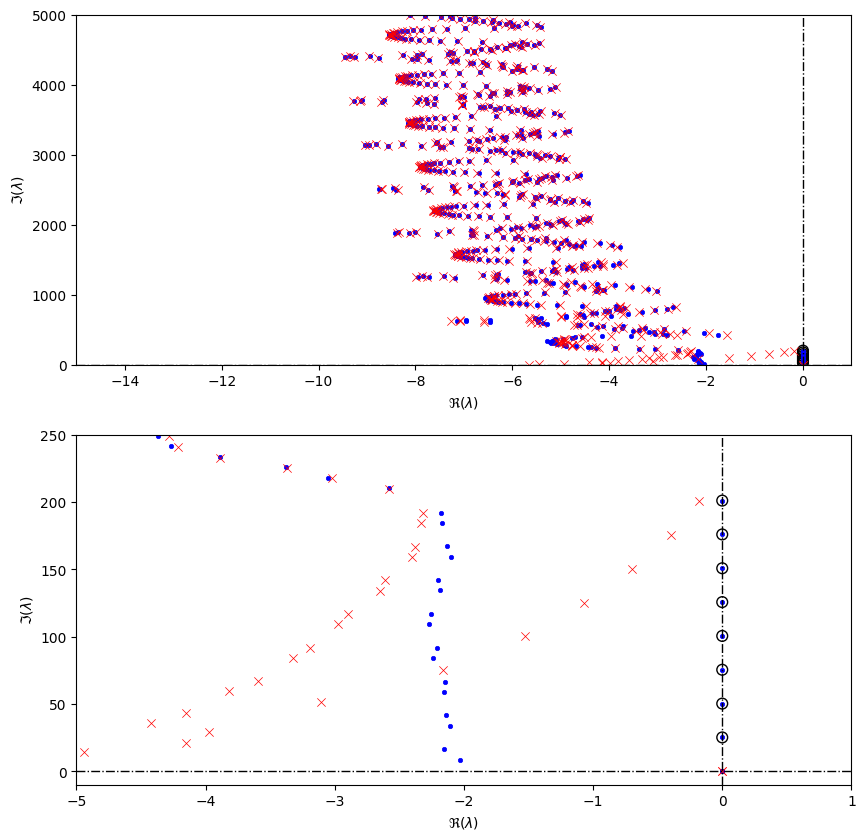

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,10))
ax1.scatter(expected_zeros.real, expected_zeros.imag, marker="o", s=60, edgecolors="k", facecolors='none')


ax2.scatter(expected_zeros.real, expected_zeros.imag, marker="o", s=60, edgecolors="k", facecolors='none')
ax2 = qpmr.plot.pole_zero(poles, zeros, ax=ax2)
ax2.set_xlim((-5, 1))
ax2.set_ylim((-10, 250)) 
plt.show()